In [1]:
!pip install pyntcloud

In [2]:
import cv2
import numpy as np
import glob
import os
import cv2 as cv
import matplotlib.pyplot as plt
from pyntcloud import PyntCloud
import pandas as pd

## Calibration

In [100]:
chessboard_size = (8, 6) 
square_size = 2.5  


objp = np.zeros((chessboard_size[0]*chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0],
                      0:chessboard_size[1]].T.reshape(-1, 2)
objp *= square_size 

imgL = cv2.imread("left_chessboard.jpg")
imgR = cv2.imread("right_chessboard.jpg")

# Check if the imahes are loaded correctly
if imgL is None or imgR is None:
    print("Cannot read the images!")
    exit()

# Convert to grayscale
grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# === Find the corner ===
retL, cornersL = cv2.findChessboardCorners(grayL, chessboard_size, None)
retR, cornersR = cv2.findChessboardCorners(grayR, chessboard_size, None)

if not retL or not retR:
    print("Cannot find chessboard corners in one or both images!")
    exit()
else:
    print("Found chessboard corners in both images!")


cv2.drawChessboardCorners(imgL, chessboard_size, cornersL, retL)
cv2.drawChessboardCorners(imgR, chessboard_size, cornersR, retR)

cv2.imshow("Left", imgL)
cv2.imshow("Right", imgR)
cv2.waitKey(1000)
cv2.destroyAllWindows()
# === STEREO CALIBRATION ===
objpoints = [objp]
imgpointsL = [cornersL]
imgpointsR = [cornersR]


retL, mtxL, distL, _, _ = cv2.calibrateCamera(
    objpoints, imgpointsL, grayL.shape[::-1], None, None)
retR, mtxR, distR, _, _ = cv2.calibrateCamera(
    objpoints, imgpointsR, grayR.shape[::-1], None, None)

flags = 0
flags |= cv2.CALIB_FIX_INTRINSIC  
criteria = (cv2.TERM_CRITERIA_EPS +
            cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)


retS, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
    objpoints, imgpointsL, imgpointsR,
    mtxL, distL, mtxR, distR,
    grayL.shape[::-1], criteria=criteria, flags=flags)

# === RECTIFICATION + Q ===
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    mtxL, distL, mtxR, distR,
    grayL.shape[::-1], R, T
)

# Save the parameters to a file
np.savez("stereo_2images_params.npz",
         mtxL=mtxL, distL=distL,
         mtxR=mtxR, distR=distR,
         R=R, T=T, Q=Q)
focal_length_x = mtxL[0, 0]
focal_length_y = mtxL[1, 1]
focal_length = (focal_length_x + focal_length_y) / 2
optical_center_x = mtxL[0, 2]
optical_center_y = mtxL[1, 2]
print("Focal length:", focal_length)
print("Optical center:", (optical_center_x, optical_center_y))

Found chessboard corners in both images!
Focal length: 672.3441326313293
Optical center: (255.28290156040094, 251.76383070564728)


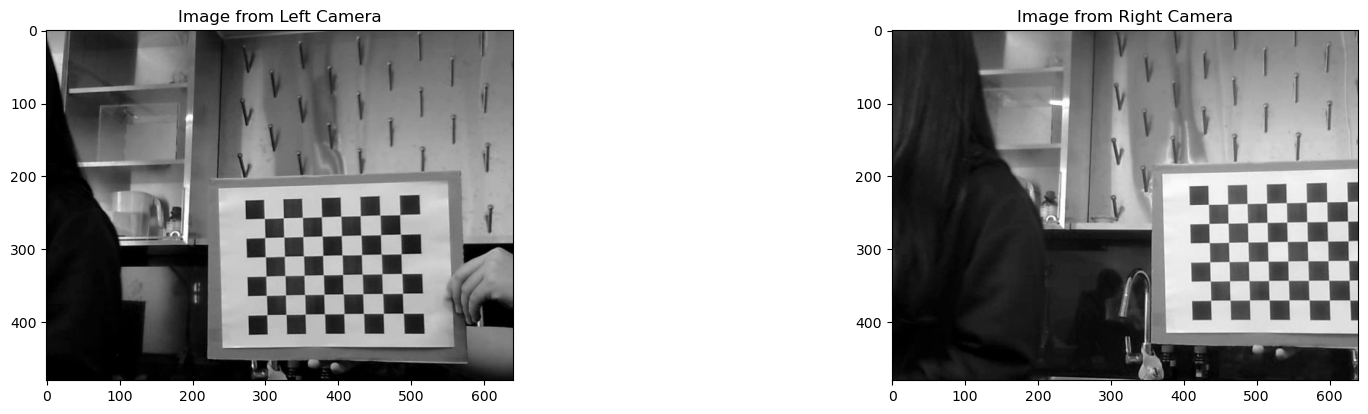

In [101]:
# Import images
imgL = cv2.imread('left_chessboard.jpg')
imgR = cv2.imread('right_chessboard.jpg')

gray_imgL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
gray_imgR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# Display images
fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(2, 2, 1); plt.imshow(gray_imgL, cmap = "gray"); ax.set_title('Image from Left Camera');
ax = fig.add_subplot(2, 2, 2); plt.imshow(gray_imgR, cmap = "gray"); ax.set_title('Image from Right Camera');

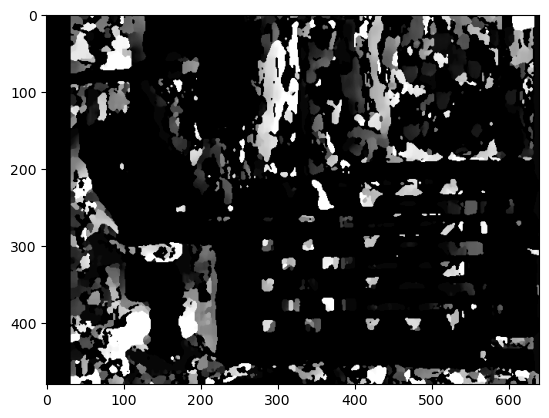

In [102]:
blur_imgL = cv.GaussianBlur(imgL, (3, 3), 0)
blur_imgR = cv.GaussianBlur(imgR, (3, 3), 0)
min_dispar = 0
dispar = 1
block = 13
kernel = 5
# Calculate disparity
stereo = cv.StereoSGBM_create(
        minDisparity = 16 * min_dispar,
        numDisparities = 32 * dispar,
        blockSize = block,
        speckleRange = 2,
        P1 = 8 * 3 * kernel ** 2, P2 = 32 * 3 * kernel ** 2)
disparity = stereo.compute(blur_imgL, blur_imgR)
plt.imshow(disparity,'gray')
plt.show()

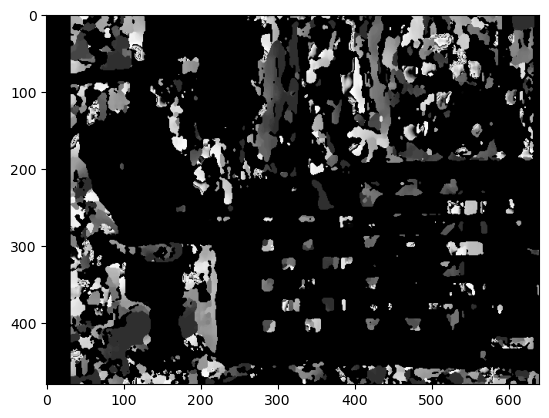

In [103]:
fx = 672    # lense focal length
baseline = 13.5  # distance in mm between the two cameras
units = 0.5   # depth units, adjusted for the output to fit in one byte
valid_pixels = disparity > 0
depth_map = np.zeros(shape=gray_imgL.shape).astype(np.uint8)  # Initialize depth map
depth_map[valid_pixels] = (fx * baseline) / (units * (disparity[valid_pixels]))  # Avoid division by zero
depth_map = cv2.equalizeHist(depth_map)
plt.imshow(depth_map, cmap='gray')

# Check distance

In [136]:
import cv2
import numpy as np

# === LOAD VIDEO ===
left_video = cv2.VideoCapture('left.mp4')
right_video = cv2.VideoCapture('right.mp4')

kernel = 5
min_dispar = 5
dispar = 5
block = 18
# Get depth map using stereo calibration parameters
fx = 672  # Focal length from the camera matrix
baseline = 13.5  # Baseline between the two cameras
units = 0.5   # Depth units (adjust to your scale)

if not left_video.isOpened() or not right_video.isOpened():
    print("Failed to open video files!")
    exit()

# === CHESSBOARD SIZE ===
chessboard_size = (8, 6)  # Number of inner corners (width, height)
square_size = 2.5  # in cm

# Object points in 3D space
objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)
objp *= square_size  

# === STEREO MATCHING AND DISTANCE DETECTION ===
# Calculate disparity
stereo = cv2.StereoSGBM_create(
    minDisparity=16 * min_dispar,
    numDisparities=32 * dispar,
    blockSize=block,
    speckleRange=2,
    P1=8 * 3 * kernel ** 2, P2=32 * 3 * kernel ** 2)

# === VIDEO WRITER ===
frame_rate = left_video.get(cv2.CAP_PROP_FPS)  # Get the correct frame rate from the left video
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec for video output (XVID)

# Create two separate output videos
left_output_video = cv2.VideoWriter('check_distance.mp4', fourcc, frame_rate, 
                                    (int(left_video.get(3)), int(left_video.get(4))))
depth_output_video = cv2.VideoWriter('check_distance_depth.mp4', fourcc, frame_rate, 
                                     (int(left_video.get(3)), int(left_video.get(4))))

while True:
    ret_left, left_frame = left_video.read()
    ret_right, right_frame = right_video.read()
     
    if not ret_left or not ret_right:
        print("End of video!")
        break

    # === CONVERT TO GRAYSCALE ===
    gray_left = cv2.cvtColor(left_frame, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(right_frame, cv2.COLOR_BGR2GRAY)

    # Blur images to remove noises
    blur_imgL = cv2.GaussianBlur(gray_left, (kernel, kernel), 0)
    blur_imgR = cv2.GaussianBlur(gray_right, (kernel, kernel), 0)
    
    # === FIND CHESSBOARD CORNERS ===
    ret_left_corners, corners_left = cv2.findChessboardCorners(gray_left, chessboard_size, None)

    # If chessboard is found in both frames
    if ret_left_corners:
        # Calculate disparity
        disparity = stereo.compute(blur_imgL, blur_imgR)
        valid_pixels = disparity > 0
        depth_map = np.zeros(shape=gray_left.shape, dtype=np.uint8)  # Initialize depth map with float32
        depth_map[valid_pixels] = (fx * baseline) / (units * (disparity[valid_pixels]))  # Avoid division by zero
        # Normalize depth map for visualization
        # depth_map = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        depth_map = cv2.equalizeHist(depth_map)

        # Draw the corners on the images for visualization
        cv2.drawChessboardCorners(left_frame, chessboard_size, corners_left, ret_left_corners)
        
        # === CALCULATE DISTANCE TO CHESSBOARD ===
        x_min = int(min(corners_left[:, 0, 0]))
        x_max = int(max(corners_left[:, 0, 0]))
        y_min = int(min(corners_left[:, 0, 1]))
        y_max = int(max(corners_left[:, 0, 1]))
        
        # Calculate the depth of the chessboard
        # Get the depth value at the center of the chessboard
        chessboard_depth = depth_map[y_max, x_max]        
        # Check if the chessboard is too close (less than 50 cm)
        warning_text = "Distance too close!"  # Warning message for chessboard

        if chessboard_depth < 50:
            cv2.putText(left_frame, warning_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.rectangle(left_frame, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)  # Red for warning
            cv2.rectangle(depth_map, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
            cv2.putText(depth_map, warning_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
        
    # === DISPLAY RESULTS ===
    cv2.imshow('Left Frame with Chessboard Detection', left_frame)
    cv2.imshow('Depth Map', depth_map)

    # Write the left frame with the warning to the video output
    left_output_video.write(left_frame)

    # Write the depth map with the warning to the video output
    depth_output_video.write(cv2.cvtColor(depth_map, cv2.COLOR_GRAY2BGR))  # Convert depth map to color for visualization

    # Wait for 'q' key to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
left_video.release()
right_video.release()
left_output_video.release()
depth_output_video.release()
cv2.destroyAllWindows()

End of video!


# Point cloud

In [110]:
def scale(value, min_dispar, num_dispar):
    return (value / (16 ** 2) - min_dispar) / num_dispar

def disparity_helper(imgL, imgR, params):
    """
    Return the disparity accordingly to the input images and parameters
    """
    # Get parameters
    kernel, min_dispar, dispar, block = params["kernel"], params["min_disparity"], params["disparity"], params["block"]
    
    # Blur images to remove noises
    blur_imgL = cv.GaussianBlur(imgL, (kernel, kernel), 0)
    blur_imgR = cv.GaussianBlur(imgR, (kernel, kernel), 0)
    
    # Calculate disparity
    stereo = cv.StereoSGBM_create(
        minDisparity = 16 * min_dispar,
        numDisparities = 16 * dispar,
        blockSize = block,
        speckleRange = 2,
        P1 = 8 * 3 * kernel ** 2, P2 = 32 * 3 * kernel ** 2)

    # Return disparity
    return stereo.compute(blur_imgL, blur_imgR)


def calculate_disparity_dim(imgL, imgR, params):
    """
    Calculate the disparity given a specific dimension and parameters
    """
    # Deep copy
    imgL, imgR = imgL.copy(), imgR.copy()
    
    # Resize
    dim = params["dimension"]
    resized_imgL, resized_imgR = cv.resize(imgL, dim), cv.resize(imgR, dim) # Resize
    
    # Calculate disparity and return
    return disparity_helper(resized_imgL, resized_imgR, params)


def return_disparity(imgL, imgR):
    """
    Calculate the disparity of the input images
    """
    # Original dimension
    dim = imgL.shape[::-1]
    
    # 720p
    hi_params = {"dimension": (1280, 720), "kernel": 3, "block": 20,
              "min_disparity": 5, "disparity": 8}
    hi_disparity = calculate_disparity_dim(imgL, imgR, hi_params)
    
    # 360p
    mid_params = {"dimension": (640, 360), "kernel": 5, "block": 18,
              "min_disparity": 0, "disparity": 8}
    mid_disparity = calculate_disparity_dim(imgL, imgR, mid_params)
    
    # 180p
    low_params = {"dimension": (320, 180), "kernel": 7, "block": 15,
              "min_disparity": 0, "disparity": 5}
    low_disparity = calculate_disparity_dim(imgL, imgR, low_params)
    
    # Resize and normalize
    high = scale(cv.resize(hi_disparity, dim), hi_params["min_disparity"], hi_params["disparity"])
    mid = scale(cv.resize(mid_disparity, dim), mid_params["min_disparity"], mid_params["disparity"])
    low = scale(cv.resize(low_disparity, dim), low_params["min_disparity"], low_params["disparity"])
    
    return high, mid, low

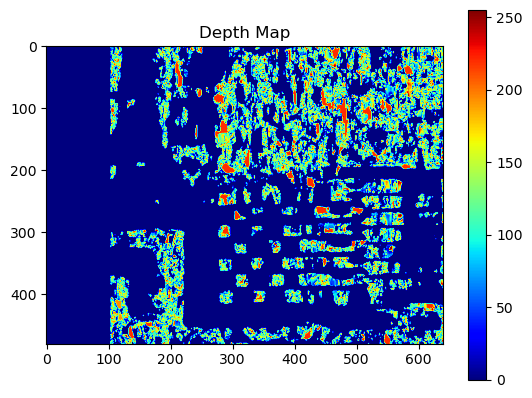

In [106]:
import open3d as o3d
import numpy as np
import cv2

hi, mid, low  = return_disparity(gray_imgL, gray_imgR)
fx = 672     # lense focal length
baseline = 13.2  # distance in mm between the two cameras
disparities = 128 # num of disparities to consider
block = 18       # block size to match
units = 0.5     # depth units, adjusted for the output to fit in one byte
valid_pixels = hi > 0
depth_map = np.zeros(shape=grayL.shape).astype("uint8")
depth_map[valid_pixels] = (fx * baseline) / (units * hi[valid_pixels])
# visualize depth data
depth_map = cv2.equalizeHist(depth_map)
# Generate point cloud from depth map
height, width = depth_map.shape
fx = focal_length_x
fy = focal_length_y
cx = optical_center_x
cy = optical_center_y

# Create 3D point cloud
points = []
colors = []

for v in range(height):
    for u in range(width):
        Z = depth_map[v, u]  # Depth value (distance)
        if Z > 0:  # Only consider points with valid depth
            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy
            points.append([X, Y, Z])
            colors.append(imgL[v, u])
            
# Convert to NumPy arrays
points = np.array(points)
colors = np.array(colors)
colors_rgb = cv2.cvtColor(colors.reshape(-1, 1, 3), cv2.COLOR_BGR2RGB).reshape(-1, 3)

# Convert to numpy array
points = np.array(points)
colors = np.array(colors)

# Show the depth map
plt.imshow(depth_map, cmap='jet')  # Use a colormap like 'jet' for visualization
plt.title('Depth Map')
plt.colorbar()
plt.show()

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors_rgb / 255.0)

# Visualize
o3d.visualization.draw_geometries([pcd], window_name="Accurate 3D Point Cloud")